In [1]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"andreslatorrevasquez","key":"86dd58cc84ffc1f2378a9ffea6ab9ac0"}'}

In [2]:
!pip install kaggle -q
import os

In [3]:
# Crear directorio oculto para la API de Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)

In [4]:
# Mover el archivo kaggle.json subido al directorio correcto
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
# Descargar y descomprimir el dataset directamente en la máquina de Colab
!kaggle datasets download -d faysalmiah1721758/potato-dataset --unzip
print("Dataset descargado y extraído correctamente.")

Dataset URL: https://www.kaggle.com/datasets/faysalmiah1721758/potato-dataset
License(s): CC0-1.0
100% 37.8M/37.8M [00:00<00:00, 84.5MB/s]

Dataset descargado y extraído correctamente.


In [6]:
!ls

Potato___Early_blight  Potato___healthy  Potato___Late_blight  sample_data


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Definir hiperparámetros de infraestructura
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Tamaño estándar para arquitecturas como MobileNet o ResNet
DATA_DIR = "."

# Conteo de distribución
clases = os.listdir(DATA_DIR)
for clase in clases:
    num_imgs = len(os.listdir(os.path.join(DATA_DIR, clase)))
    print(f"Clase '{clase}': {num_imgs} imágenes")

# Creación del pipeline de Entrenamiento (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Creación del pipeline de Validación (20%)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(f"Clases detectadas en el pipeline: {class_names}")

Clase '.config': 10 imágenes
Clase 'Potato___healthy': 152 imágenes
Clase 'Potato___Early_blight': 1000 imágenes
Clase 'Potato___Late_blight': 1000 imágenes
Clase 'sample_data': 6 imágenes
Found 2152 files belonging to 4 classes.
Using 1722 files for training.
Found 2152 files belonging to 4 classes.
Using 430 files for validation.
Clases detectadas en el pipeline: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'sample_data']


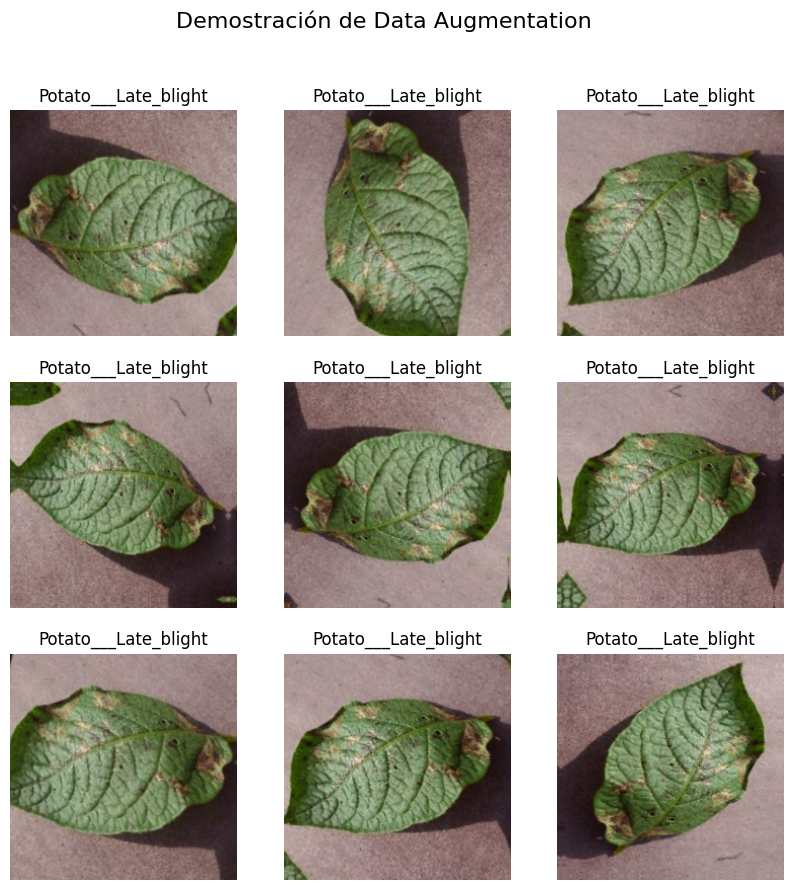

In [8]:
from tensorflow.keras import layers

# Definir la capa de aumento de datos secuencial
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2), # Rotación aleatoria del 20%
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1)  # Variación para simular distintas iluminaciones
])

# Visualizar el efecto del Data Augmentation para la presentación
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    # Tomar la primera imagen del batch
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Aplicar el aumento a la misma imagen
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255.0) # Normalizar para matplotlib
        plt.title(class_names[labels[0]])
        plt.axis("off")
plt.suptitle("Demostración de Data Augmentation", fontsize=16)
plt.show()

In [9]:
# AUTOTUNE delega a TensorFlow la gestión del tamaño del buffer en tiempo de ejecución
AUTOTUNE = tf.data.AUTOTUNE

# Aplicar las optimizaciones de I/O
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Pipelines de datos optimizados en memoria estática y asíncrona.")

Pipelines de datos optimizados en memoria estática y asíncrona.
